# Self-Supervised Learning for Satellite Image Representation Learning

Bu model uydu görüntülerinde SSL mantığını gösterir.

- Dataset: EuroSAT RGB satellite images
- SSL method: SimCLR-style contrastive learning
- Encoder: ResNet18
- Pretraining: label kullanılmaz
- Evaluation: frozen encoder + az etiketli linear classifier

Önemli: Dataset etiketli olsa bile SSL pretraining aşamasında etiketler tamamen yok sayılır. Etiketler sadece son linear evaluation aşamasında ve küçük bir oranla kullanılır.

Bu hücre projede gerekli Python kütüphanelerini kurar. PyTorch model eğitimi için, torchvision görüntü işlemleri için, scikit-learn değerlendirme için, matplotlib grafik çizimi için kullanılır.


In [1]:
!pip install torch torchvision scikit-learn matplotlib numpy pandas tqdm -q

Bu hücre gerekli kütüphaneleri içe aktarır ve sabit rastgelelik değeri belirler. Ayrıca eğitim GPU’da mı CPU’da mı çalışacak onu seçer; böylece sonuçlar daha kontrollü ve tekrar üretilebilir olur.


In [2]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.datasets import EuroSAT
from torchvision.models import resnet18

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## Dataset indir

Bu hücre EuroSAT uydu görüntüsü veri setini indirir ve temel dönüşümleri uygular. Görüntüler 64x64 boyutuna getirilir, tensöre çevrilir ve sınıf isimleri okunur.


In [3]:
DATA_DIR = "/content/eurosat_data"

base_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = EuroSAT(root=DATA_DIR, download=True, transform=base_transform)
class_names = dataset.classes

print("Dataset size:", len(dataset))
print("Classes:", class_names)

100%|██████████| 94.3M/94.3M [00:00<00:00, 283MB/s]


Dataset size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Örnek görüntüler

Bu hücre veri setinden örnek uydu görüntülerini gösterir. Böylece modelin hangi tür görüntülerle çalıştığını ve sınıfların nasıl göründüğünü görsel olarak kontrol ederiz.


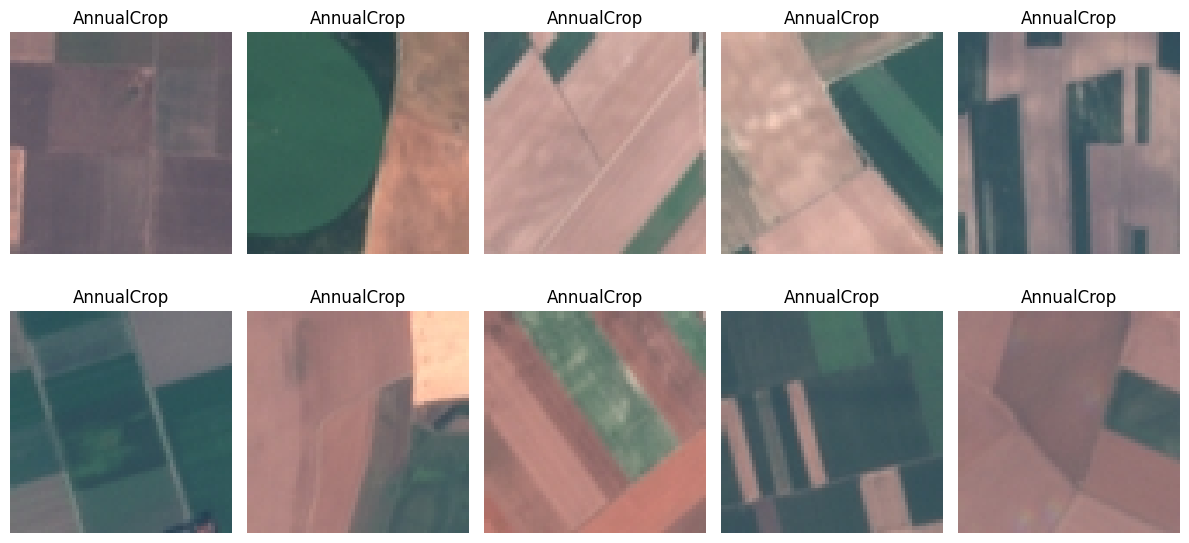

In [4]:
plt.figure(figsize=(12, 6))
for i in range(10):
    img, label = dataset[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[label])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Mini SSL setup

Bu hücre SSL ve değerlendirme için veri bölme işlemini yapar. SSL kısmında etiketler kullanılmadan görüntüler seçilir; sonrasında az miktarda etiketli veri ve ayrı test verisi hazırlanır.


In [5]:
SSL_SAMPLE_SIZE = 6000
LABEL_FRACTION = 0.05

all_indices = np.arange(len(dataset))
labels = np.array([dataset[i][1] for i in all_indices])

ssl_indices = np.random.choice(all_indices, size=min(SSL_SAMPLE_SIZE, len(dataset)), replace=False)

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

train_labels = labels[train_indices]

limited_train_indices, _ = train_test_split(
    train_indices,
    train_size=LABEL_FRACTION,
    random_state=SEED,
    stratify=train_labels
)

print("SSL unlabeled-like samples:", len(ssl_indices))
print("Limited labeled train samples:", len(limited_train_indices))
print("Test samples:", len(test_indices))

SSL unlabeled-like samples: 6000
Limited labeled train samples: 1080
Test samples: 5400


## SimCLR augmentations

Bu hücre iki farklı görüntü dönüşümü tanımlar. SSL dönüşümü aynı görüntüden iki farklı artırılmış versiyon üretmek için kullanılır; eval dönüşümü ise test ve doğrusal değerlendirme için sade dönüşümdür.


In [6]:
ssl_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomResizedCrop(size=64, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

## Dataset sınıfları

Bu hücre özel Dataset sınıflarını oluşturur. SSLDataset aynı görüntünün iki farklı artırılmış halini döndürür; EvalDataset ise görüntüyü etiketiyle birlikte döndürür.


In [7]:
class SSLDataset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_path, _ = self.base_dataset.samples[real_idx]
        img = self.base_dataset.loader(img_path)
        x1 = self.transform(img)
        x2 = self.transform(img)
        return x1, x2

class EvalDataset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_path, label = self.base_dataset.samples[real_idx]
        img = self.base_dataset.loader(img_path)
        img = self.transform(img)
        return img, label

## DataLoader

Bu hücre DataLoader yapıları oluşturur. DataLoader veriyi batch’ler halinde modele verir; SSL eğitimi, sınırlı etiketli eğitim ve test için ayrı yükleyiciler hazırlanır.


In [8]:
BATCH_SIZE = 128

ssl_loader = DataLoader(
    SSLDataset(dataset, ssl_indices, ssl_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=2
)

limited_train_loader = DataLoader(
    EvalDataset(dataset, limited_train_indices, eval_transform),
    batch_size=256,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    EvalDataset(dataset, test_indices, eval_transform),
    batch_size=256,
    shuffle=False,
    num_workers=2
)

print("SSL batches:", len(ssl_loader))

SSL batches: 46


## Model

Bu hücre SimCLR tarzı modeli kurar. ResNet18 encoder görüntüden özellik çıkarır, projector ise bu özellikleri contrastive learning kaybı için daha küçük bir temsil uzayına taşır.


In [9]:
class SimCLRModel(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.encoder = backbone
        self.projector = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z

model = SimCLRModel().to(device)
print("Model ready")

Model ready


## NT-Xent Loss

Bu hücre NT-Xent contrastive loss fonksiyonunu tanımlar. Amaç, aynı görüntüden üretilen iki farklı görünümü birbirine yaklaştırmak; farklı görüntüleri ise temsil uzayında ayırmaktır.


In [10]:
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.shape[0]

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    z = torch.cat([z1, z2], dim=0)

    similarity = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2 * batch_size, dtype=torch.bool).to(device)
    similarity = similarity.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.arange(batch_size, 2 * batch_size),
        torch.arange(0, batch_size)
    ]).to(device)

    return F.cross_entropy(similarity, positives)

## SSL pretraining

Bu hücre self-supervised training döngüsünü çalıştırır. Model etiket kullanmadan iki artırılmış görüntü üzerinden loss hesaplar, ağırlıkları günceller ve her epoch için SSL loss değerini kaydeder.


In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 10
ssl_losses = []

model.train()

for epoch in range(EPOCHS):
    total_loss = 0.0

    for x1, x2 in tqdm(ssl_loader, desc=f"SSL Epoch {epoch+1}/{EPOCHS}"):
        x1, x2 = x1.to(device), x2.to(device)

        _, z1 = model(x1)
        _, z2 = model(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(ssl_loader)
    ssl_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - SSL Loss: {avg_loss:.4f}")

SSL Epoch 1/10: 100%|██████████| 46/46 [00:23<00:00,  1.95it/s]


Epoch 1/10 - SSL Loss: 4.8049


SSL Epoch 2/10: 100%|██████████| 46/46 [00:17<00:00,  2.63it/s]


Epoch 2/10 - SSL Loss: 4.6040


SSL Epoch 3/10: 100%|██████████| 46/46 [00:16<00:00,  2.79it/s]


...

Epoch 8/10 - SSL Loss: 4.1811


SSL Epoch 9/10: 100%|██████████| 46/46 [00:16<00:00,  2.77it/s]


Epoch 9/10 - SSL Loss: 4.1756


SSL Epoch 10/10: 100%|██████████| 46/46 [00:17<00:00,  2.60it/s]

Epoch 10/10 - SSL Loss: 4.1430


## SSL loss curve

Bu hücre SSL eğitim loss grafiğini çizer. Loss’un epoch ilerledikçe düşmesi, modelin görüntülerden daha iyi temsil öğrenmeye başladığını gösterir.


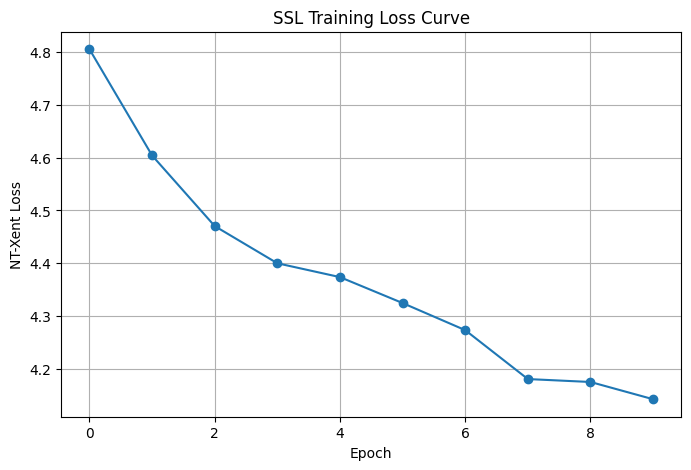

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(ssl_losses, marker="o")
plt.title("SSL Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.grid(True)
plt.show()

## Embedding çıkar

Bu hücre eğitilmiş encoder ile görüntülerden embedding çıkarır. Bu embedding’ler görüntülerin sayısal özellik temsilleridir ve sonraki adımda basit bir sınıflandırıcı ile test edilir.


In [13]:
def extract_embeddings(model, loader):
    model.eval()
    embeddings, labels_out = [], []

    with torch.no_grad():
        for imgs, y in tqdm(loader):
            imgs = imgs.to(device)
            h = model.encoder(imgs)
            embeddings.append(h.cpu().numpy())
            labels_out.extend(y.numpy())

    return np.vstack(embeddings), np.array(labels_out)

train_embeddings, train_labels = extract_embeddings(model, limited_train_loader)
test_embeddings, test_labels = extract_embeddings(model, test_loader)

print("Train embeddings:", train_embeddings.shape)
print("Test embeddings:", test_embeddings.shape)

100%|██████████| 22/22 [00:02<00:00,  9.47it/s]

Train embeddings: (1080, 512)
Test embeddings: (5400, 512)


## Linear evaluation

 SSL ile öğrenilen embedding’lerin ne kadar faydalı olduğunu ölçmek için az etiketli veriyle Logistic Regression eğitilir ve test doğruluğu hesaplanır.


In [14]:
linear_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED
)

linear_clf.fit(train_embeddings, train_labels)
test_preds = linear_clf.predict(test_embeddings)

acc = accuracy_score(test_labels, test_preds)

print("Linear Evaluation Accuracy:", round(acc, 4))
print()
print(classification_report(test_labels, test_preds, target_names=class_names))

Linear Evaluation Accuracy: 0.6865

                      precision    recall  f1-score   support

          AnnualCrop       0.76      0.70      0.73       600
              Forest       0.85      0.90      0.88       600
HerbaceousVegetation       0.58      0.50      0.54       600
             Highway       0.43      0.42      0.42       500
          Industrial       0.80      0.79      0.80       500
             Pasture       0.45      0.60      0.51       400
       PermanentCrop       0.50      0.52      0.51       500
         Residential       0.86      0.91      0.88       600
               River       0.52      0.47      0.49       500
             SeaLake       0.97      0.94      0.95       600

            accuracy                           0.69      5400
           macro avg       0.67      0.67      0.67      5400
        weighted avg       0.69      0.69      0.69      5400



## Confusion matrix

Hangi sınıfların doğru tahmin edildiğini ve hangi sınıfların birbirine karıştırıldığını görsel olarak analiz etmemizi sağlar.


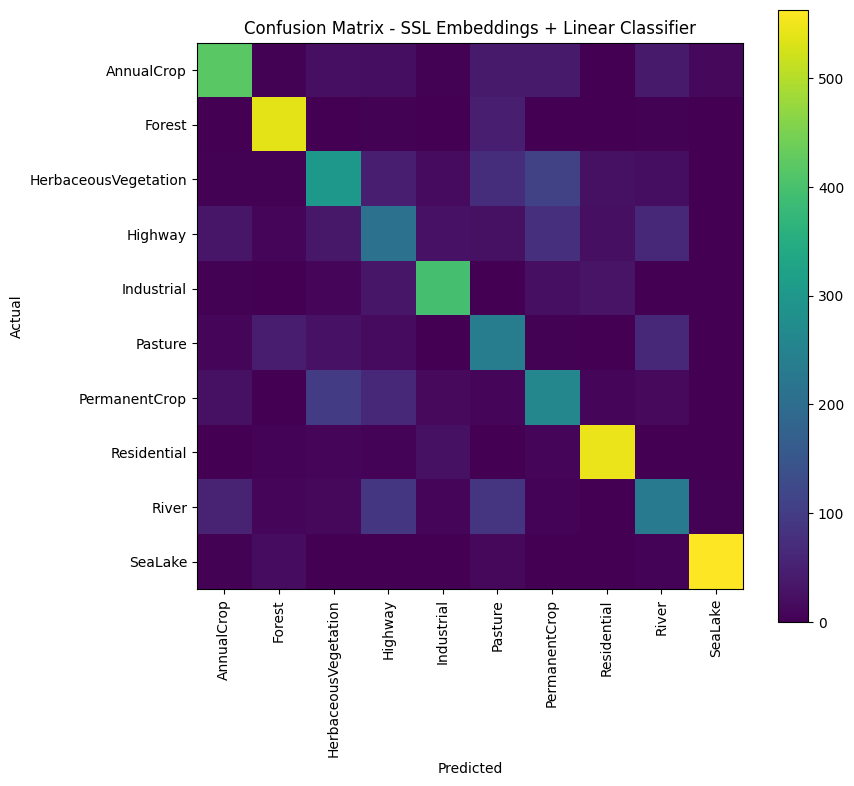

In [15]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(9, 8))
plt.imshow(cm)
plt.title("Confusion Matrix - SSL Embeddings + Linear Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

Bu grafik modelin hangi sınıfları doğru veya yanlış tahmin ettiğini gösteriyor. Satırlar gerçek sınıfları, sütunlar ise modelin tahmin ettiği sınıfları temsil ediyor.

Köşegen üzerindeki parlak değerler doğru tahminleri gösteriyor. Yani model o sınıfı doğru öğrenmiş demek. Örneğin Forest, Residential ve SeaLake sınıflarında yüksek doğruluk görüyoruz.

Köşegen dışındaki değerler ise karışan sınıfları gösteriyor. Örneğin bazı tarım ve bitki örtüsü sınıfları birbirine benzediği için model bunları zaman zaman karıştırabiliyor.

Bu sonuç SSL’in görüntülerden anlamlı feature’lar öğrenebildiğini gösteriyor çünkü model tamamen etiketli eğitim almadan sınıflar arasında ayrım yapabiliyor.

## t-SNE visualization

Bu hücre t-SNE görselleştirmesi yapar. Yüksek boyutlu embedding’leri 2 boyuta indirerek modelin benzer sınıfları temsil uzayında ne kadar yakın tuttuğunu görmemizi sağlar.


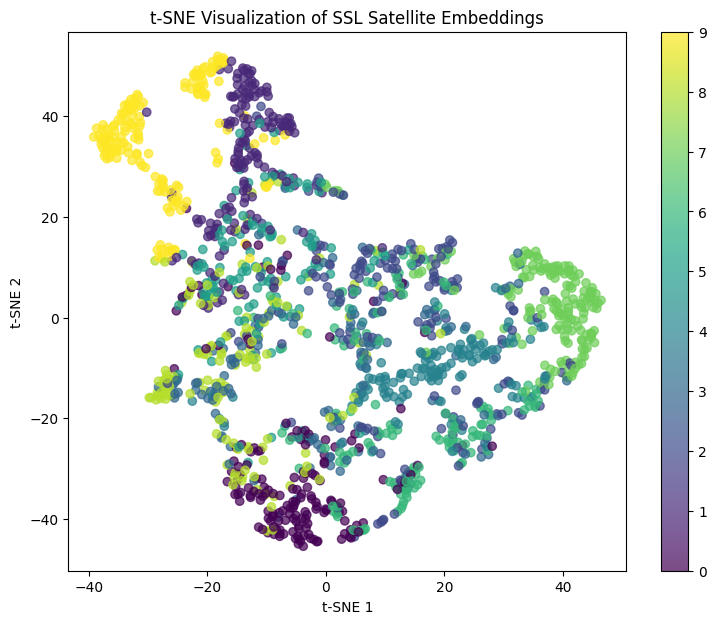

In [16]:
sample_size = min(1500, len(test_embeddings))
idx = np.random.choice(len(test_embeddings), sample_size, replace=False)

emb_sample = test_embeddings[idx]
label_sample = test_labels[idx]

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca", learning_rate="auto")
emb_2d = tsne.fit_transform(emb_sample)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=label_sample, alpha=0.7)
plt.title("t-SNE Visualization of SSL Satellite Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, ticks=range(len(class_names)))
plt.show()

görüntü tahmini

tek bir test görüntüsü için tahmin yapar. Görüntüyü gösterir, gerçek sınıfı ve modelin tahmin ettiği sınıfı yazar; ayrıca tahmin güven skorunu verir.


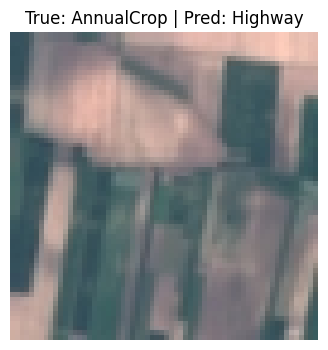

Prediction: Highway
True label: AnnualCrop
Confidence: 0.3878


In [17]:
def predict_single_image(index):
    img_path, true_label = dataset.samples[index]
    pil_img = dataset.loader(img_path)

    x = eval_transform(pil_img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        emb = model.encoder(x).cpu().numpy()

    pred = linear_clf.predict(emb)[0]
    probs = linear_clf.predict_proba(emb)[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(pil_img)
    plt.axis("off")
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred]}")
    plt.show()

    print("Prediction:", class_names[pred])
    print("True label:", class_names[true_label])
    print("Confidence:", round(float(np.max(probs)), 4))

random_index = int(np.random.choice(test_indices))
predict_single_image(random_index)

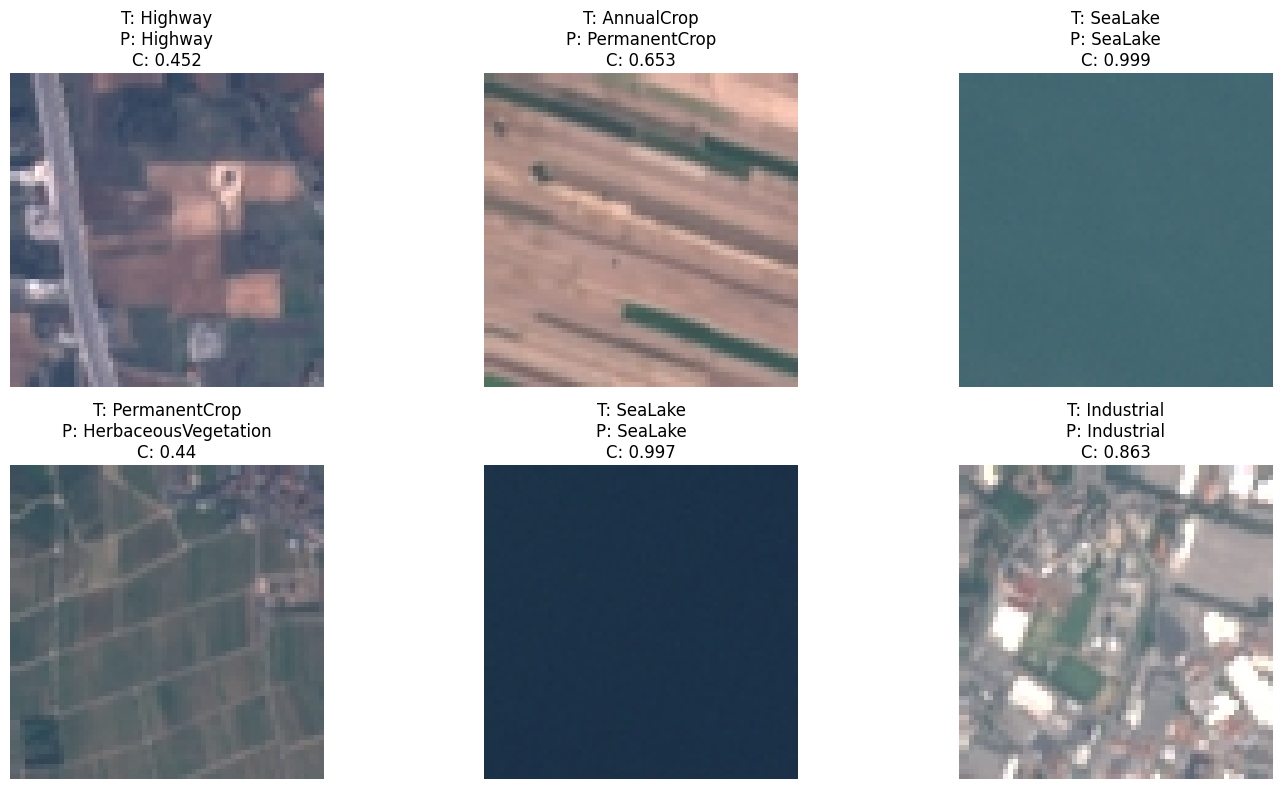

In [18]:
def predict_multiple_images(num_images=6):
    model.eval()

    selected_indices = np.random.choice(test_indices, num_images, replace=False)

    plt.figure(figsize=(15, 8))

    for i, idx in enumerate(selected_indices):
        img_path, true_label = dataset.samples[idx]
        pil_img = dataset.loader(img_path)

        x = eval_transform(pil_img).unsqueeze(0).to(device)

        with torch.no_grad():
            emb = model.encoder(x).cpu().numpy()

        pred = linear_clf.predict(emb)[0]
        probs = linear_clf.predict_proba(emb)[0]
        confidence = round(float(np.max(probs)), 3)

        plt.subplot(2, (num_images + 1) // 2, i + 1)
        plt.imshow(pil_img)
        plt.axis("off")

        plt.title(
            f"T: {class_names[true_label]}\n"
            f"P: {class_names[pred]}\n"
            f"C: {confidence}"
        )

    plt.tight_layout()
    plt.show()

# Çalıştır
predict_multiple_images(num_images=6)

## Proje özeti

In [19]:
print("PROJECT SUMMARY")
print("-" * 60)
print("Project: Self-Supervised Learning for Satellite Image Representation Learning")
print("Dataset: EuroSAT RGB satellite images")
print("SSL method: SimCLR-style contrastive learning")
print("Encoder: ResNet18")
print("Pretraining labels used: No")
print(f"SSL samples used as unlabeled: {len(ssl_indices)}")
print(f"Labeled samples used for linear evaluation: {len(limited_train_indices)}")
print(f"Test samples: {len(test_indices)}")
print(f"Final SSL Loss: {ssl_losses[-1]:.4f}")
print(f"Linear Evaluation Accuracy: {acc:.4f}")

PROJECT SUMMARY
------------------------------------------------------------
Project: Self-Supervised Learning for Satellite Image Representation Learning
Dataset: EuroSAT RGB satellite images
SSL method: SimCLR-style contrastive learning
Encoder: ResNet18
Pretraining labels used: No
SSL samples used as unlabeled: 6000
Labeled samples used for linear evaluation: 1080
Test samples: 5400
Final SSL Loss: 4.1430
Linear Evaluation Accuracy: 0.6865


## özet

Bu projede EuroSAT uydu görüntüleri üzerinde Self-Supervised Learning kullandım. Model, ön eğitim aşamasında görüntü etiketlerini kullanmadı. Yaklaşık 6000 görüntü etiketsiz veri gibi değerlendirilerek SimCLR tabanlı contrastive learning yöntemiyle eğitildi. Bu aşamada amaç, görüntüler arasındaki benzerlikleri öğrenerek güçlü görsel temsiller elde etmekti. Feature extraction için ResNet18 tabanlı bir encoder kullanıldı.

Daha sonra modelin öğrendiği temsil gücünü ölçmek için linear evaluation uygulandı. Bu aşamada yalnızca 1080 etiketli örnek kullanılarak basit bir classifier eğitildi. Sonuç olarak model, 5400 test görüntüsü üzerinde yaklaşık %68.65 doğruluk elde etti.”



“Bu sonuç, modelin etiket kullanılmadan anlamlı görsel özellikler öğrenebildiğini göstermektedir. SSL aşamasında model doğrudan sınıf öğrenmek yerine görüntülerin yapısal benzerliklerini öğrenmiştir. Daha sonra az miktarda etiketli veriyle yapılan linear evaluation sonucunda elde edilen doğruluk, öğrenilen feature’ların kullanılabilir ve anlamlı olduğunu göstermektedir."